# Project 7: Customer Segmentation for an Online Store Using ML Clustering and Dimensionality Reduction Algorithms

## Problem Statement

In this project, we address a real-world marketing business problem by segmenting customers based on their purchasing power, order frequency, and recency of their last order, and determining the optimal strategy for engaging with them.

Marketing is a critical component of any business. To increase a company's profitability, understanding customers—their desires and preferences—is essential. With the rise of e-commerce, collecting and analyzing customer data, identifying patterns, and executing marketing campaigns has become significantly easier.

Most online stores use web analytics tools to track page views, visitor counts, behavior, and bounce rates. However, reports from tools like Google Analytics may not provide a complete picture of how customers interact with a website. Companies need to quickly and accurately respond to changes in customer behavior by developing tools that detect these changes in near real-time.

Machine learning enables platforms to analyze vast amounts of visitor data, identify professional buyer behavior patterns, categorize customers (e.g., loyal, promising, new, dormant, or churned), and select the appropriate engagement strategy.

Companies leveraging machine learning in their e-commerce platforms can continuously improve business processes, such as personalizing product selections for each customer and offering prices aligned with their budget. This task relates to building recommender systems, which will be covered in a later section of the course.

**Business Task:**

Segment existing customers, interpret these segments, and define strategies for engaging with them.

**Technical Task for a Data Scientist:** 

Build a customer clustering model based on their purchasing power, order frequency, and recency of their last purchase, and define the profile of each cluster.

**Main Objectives:**

1. `Preprocess the dataset.`

2. `Conduct exploratory data analysis to identify key patterns.`

3. `Create product and customer categories.`

4. `Build multiple machine learning clustering models, determine the optimal number of clusters, and interpret them.`

5. `Design a process to predict customer interest categories and test the model on new customers.`

In [1]:
#from comet_ml import Experiment

#@Customer Segmentation for an Online Store Using ML Clustering and Dimensionality Reduction Algorithms

api_key=""
project_name="Clustering and Dimensionality Reduction Algorithms"
workspace=""

In [2]:
# Start the experiment

#experiment = Experiment(project_name=project_name, workspace=workspace, api_key = api_key, log_code=True)

In [3]:
# Load the libraries

import time
from collections import Counter

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
plt.style.use('seaborn-v0_8')
plt.rcParams["patch.force_edgecolor"] = True

import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn import mixture, cluster
from sklearn import preprocessing, model_selection, pipeline
from sklearn import decomposition, compose, manifold
from sklearn import ensemble
from sklearn import metrics

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from IPython.display import display, HTML

## 1. Data Exploration

In [4]:
import warnings 
warnings.filterwarnings("ignore")

In [5]:
# Read the data

data = pd.read_csv(
    'data/customer_segmentation_project.csv', 
    encoding="ISO-8859-1", 
    dtype={'CustomerID': str,'InvoiceID': str}
)
print('Data shape: {}'.format(data.shape))
data.head(5)

Data shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom


We have data on over half a million transactions, each described by the following features:

* `InvoiceNo`: Invoice number (a unique six-digit nominal number assigned to each transaction; a leading "C" indicates a cancellation).

* `StockCode`: Product code (a unique five-digit integer assigned to each distinct product).

* `Description`: Product name.

* `Quantity`: Quantity of each product per transaction.

* `InvoiceDate`: Date and time of the invoice/transaction.

* `UnitPrice`: Unit price of the product in pounds sterling.

* `CustomerID`: Customer identifier (a unique five-digit number assigned to each customer).

* `Country`: Name of the country where the customer resides.

We will analyze the data structure.

In [6]:
# Check the data types in our dataset

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  object 
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 33.1+ MB


In [7]:
# Convert the InvoiceDate column to datetime format and determine the time period covered by the data

data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'], format='mixed')
date_old = data['InvoiceDate'].min()
date_new = data['InvoiceDate'].max()

print(f'The dataset covers the period from {date_old} to {date_new}')

The dataset covers the period from 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [8]:
# Add features for the month, day, day of the week, and hour of purchase to the transaction table

data['Month'] = pd.to_datetime(data['InvoiceDate']).dt.month
data['Date'] = pd.to_datetime(data['InvoiceDate']).dt.day
data['Day_of_week'] = pd.to_datetime(data['InvoiceDate']).dt.day_of_week
data['Hour'] = pd.to_datetime(data['InvoiceDate']).dt.hour

In [9]:
# Examine the basic statistical characteristics of numerical features

data.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,541909.0,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
Month,541909.0,7.553128,1.0,5.0,8.0,11.0,12.0,3.509055
Date,541909.0,15.023096,1.0,7.0,15.0,22.0,31.0,8.664063
Day_of_week,541909.0,2.431277,0.0,1.0,2.0,4.0,6.0,1.844709
Hour,541909.0,13.078729,6.0,11.0,13.0,15.0,20.0,2.44327


In [10]:
# We observe negative prices; investigate the cheapest product price, excluding returns

prices = data.groupby('StockCode', as_index=False)['UnitPrice'].min().sort_values(by='UnitPrice')
prices

,StockCode,UnitPrice
4038,B,-11062.06
0,10002,0.00
3568,85145,0.00
3569,85146,0.00
1754,22848,0.00
...,...,...
3356,84963B,49.95
1832,22929,57.95
3156,84632,59.95
981,22016,83.33


### **Observations**:

* Returns exist, with values reaching negative minima.

* Many products have a price of 0 pounds sterling.

* Outliers are present in the data for `UnitPrice` and `Quantity`.

In [11]:
# Examine the basic statistical characteristics of categorical features

data.describe(include='object').T

,count,unique,top,freq
InvoiceNo,541909,25900,573585,1114
StockCode,541909,4070,85123A,2313
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369
CustomerID,406829,4372,17841,7983
Country,541909,38,United Kingdom,495478


### **After analyzing categorical features, we observe:**

* Orders were placed from up to 38 countries, with the majority from the United Kingdom.

* There are **2,313 unique products**.

* There are **7,983 unique customers**.

## 2. Data Preprocessing and Cleaning

In [12]:
# Investigate missing values

missing_values = data.isnull().sum().sum()
print(f'Total number of missing values in the dataset: {missing_values}')

cols_with_nulls = data.isnull().mean()*100
print(f'Missing values by column: \n{cols_with_nulls.sort_values(ascending=False).head(5)}')

# Remove rows with missing values in CustomerID and Description

data = data.dropna(subset=['CustomerID', 'Description'])

print()
print(f'Data shape after missing values handling: {data.shape}')

Total number of missing values in the dataset: 136534
Missing values by column: 
CustomerID     24.926694
Description     0.268311
InvoiceNo       0.000000
StockCode       0.000000
Quantity        0.000000
dtype: float64

Data shape after missing values handling: (406829, 12)


In [13]:
# Check for duplicates

dublicates = data.duplicated().sum()
print(f'Number of duplicates in the data: {dublicates}')

data = data.drop_duplicates()
print(f'Data shape after dropping duplicates: {data.shape}')

Number of duplicates in the data: 5225
Data shape after dropping duplicates: (401604, 12)


We previously noticed negative values in the `Quantity` column. Let’s investigate their origin by displaying the first five rows where `Quantity` is less than 0.

In [14]:
# Investigate negative sales

negative_quantity = data[(data['Quantity']<0)]
print('Count of entries with a negative number: {}'.format(negative_quantity.shape[0]))
negative_quantity.head()

Count of entries with a negative number: 8872


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,Date,Day_of_week,Hour
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom,12,1,2,9
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom,12,1,2,9
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom,12,1,2,10
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,12,1,2,10
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,12,1,2,10


We will verify that all records with negative quantities are indeed return transactions. If a transaction is not a return but has a negative quantity, it will be considered an outlier.

In [15]:
# Create a return indicator and check if all negative transactions are returns

data['TransactionType'] = data['InvoiceNo'].apply(lambda x: 'Canceled' if x[0] == 'C' else 'Sale')
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,Date,Day_of_week,Hour,TransactionType
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,12,1,2,8,Sale
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,12,1,2,8,Sale
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,12,1,2,8,Sale
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,12,1,2,8,Sale
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,12,1,2,8,Sale


In [16]:
# Check for potential outliers (negative sales without returns)

mask = data[(data['TransactionType'] == 'Sale') & (data['Quantity'] < 0)]
print(f'Suspicious transactions in the dataset: {mask["Quantity"].sum()}')

Suspicious transactions in the dataset: 0


**All negative transactions appear to be returns at first glance**

Let’s examine returns in more detail. Currently, each unique product has a separate row, which complicates determining the total number of returns.

In [17]:
# Determine the number of unique products per unique customer-invoice pair

temp = data.groupby(by=['CustomerID', 'InvoiceNo'], as_index=False)['InvoiceDate'].count()
nb_products_per_basket = temp.rename(columns = {'InvoiceDate':'Number of products'})
nb_products_per_basket.head()

,CustomerID,InvoiceNo,Number of products
0,12346,541431,1
1,12346,C541433,1
2,12347,537626,31
3,12347,542237,29
4,12347,549222,24


We will add an `order_canceled` feature to the auxiliary table `nb_products_per_basket`, set to 1 for return transactions and 0 otherwise.


In [18]:
# Add a feature indicating return transactions

nb_products_per_basket['order_canceled'] = nb_products_per_basket['InvoiceNo'].apply(lambda x: 1 if x[0] == 'C' else 0)
share_of_returns = nb_products_per_basket['order_canceled'].sum() / len(nb_products_per_basket['InvoiceNo'])
print(f'Proportion of returns in transactions: {share_of_returns:.2%}')

Proportion of returns in transactions: 16.47%


In [19]:
# Let’s take a closer look at canceled orders:

nb_products_per_basket[nb_products_per_basket['order_canceled'] == 1].head()

,CustomerID,InvoiceNo,Number of products,order_canceled
1,12346,C541433,1,1
23,12352,C545329,2,1
24,12352,C545330,1,1
25,12352,C547388,7,1
39,12359,C549955,2,1


In [20]:
# Find all transactions for the customer with ID 12346

data[data['CustomerID'] == '12346']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,Date,Day_of_week,Hour,TransactionType
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom,1,18,1,10,Sale
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346,United Kingdom,1,18,1,10,Canceled


An example of an order-cancellation pair: Note the `StockCode`, `UnitPrice`, `CustomerID`, and `Quantity` columns — they are identical, but the second transaction is a cancellation.

We hypothesize that for every canceled transaction in the dataset (`data`), there exists a corresponding transaction with the same product code, customer ID, and opposite quantity.

In [21]:
# Test the hypothesis

hypothesis_valid = True

for idx, row in negative_quantity.iterrows():
    customer_id = row['CustomerID']
    stock_code = row['StockCode']
    quantity = -1 * row['Quantity']

    # Search for a matching record in data
    
    matching = data[
        (data['CustomerID'] == customer_id) &
        (data['StockCode'] == stock_code) &
        (data['Quantity'] == quantity)
    ]

    if matching.empty:
        hypothesis_valid = False
        print(f"Hypothesis NOT confirmed for row:\n{row}")
        break  

if hypothesis_valid:
    print("Hypothesis confirmed: Each canceled transaction has a corresponding opposite transaction.")
else:
    print("Hypothesis not confirmed.")

Hypothesis NOT confirmed for row:
InvoiceNo                  C536379
StockCode                        D
Description               Discount
Quantity                        -1
InvoiceDate    2010-12-01 09:41:00
UnitPrice                     27.5
CustomerID                   14527
Country             United Kingdom
Month                           12
Date                             1
Day_of_week                      2
Hour                             9
Name: 141, dtype: object
Hypothesis not confirmed.


In [22]:
# Examine transactions for the customer (ID 14527) where the hypothesis was not confirmed

data[data['CustomerID'] == '14527'].head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,Date,Day_of_week,Hour,TransactionType
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom,12,1,2,9,Canceled
8963,537159,22112,CHOCOLATE HOT WATER BOTTLE,6,2010-12-05 13:17:00,4.95,14527,United Kingdom,12,5,6,13,Sale
8964,537159,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-05 13:17:00,4.95,14527,United Kingdom,12,5,6,13,Sale
8965,537159,21479,WHITE SKULL HOT WATER BOTTLE,1,2010-12-05 13:17:00,3.75,14527,United Kingdom,12,5,6,13,Sale
8966,537159,22114,HOT WATER BOTTLE TEA AND SYMPATHY,6,2010-12-05 13:17:00,3.95,14527,United Kingdom,12,5,6,13,Sale


We observe the first row, which contains a canceled order (`C536379`). There is no corresponding purchase transaction. This product is marked as a discounted item (`StockCode` = `'D'`), suggesting that such transactions may not have matching positive-quantity counterparts. We will account for this in the future.

We propose **a new hypothesis**: For every canceled transaction in the dataset (`data`), there exists a corresponding transaction with the same product code, customer ID, and opposite quantity, provided the product is not discounted.

In [23]:
# Exclude rows with discounts

data_no_discount = data[data['StockCode'] != 'D']

# Filter canceled transactions

canceled_transactions = data_no_discount[data_no_discount['TransactionType'] == 'Canceled']

hypothesis_valid = True

for idx, row in canceled_transactions.iterrows():
    customer_id = row['CustomerID']
    stock_code = row['StockCode']
    quantity = -1 * row['Quantity']

    # Search for the opposite transaction
    
    matching = data_no_discount[
        (data_no_discount['CustomerID'] == customer_id) &
        (data_no_discount['StockCode'] == stock_code) &
        (data_no_discount['Quantity'] == quantity)
    ]

    if matching.empty:
        hypothesis_valid = False
        print(f"Hypothesis NOT confirmed for row:\n{row}")
        break

if hypothesis_valid:
    print("Hypothesis confirmed: Each canceled transaction has a corresponding opposite transaction.")
else:
    print("Hypothesis not confirmed.")

Hypothesis NOT confirmed for row:
InvoiceNo                                  C536383
StockCode                                   35004C
Description        SET OF 3 COLOURED  FLYING DUCKS
Quantity                                        -1
InvoiceDate                    2010-12-01 09:49:00
UnitPrice                                     4.65
CustomerID                                   15311
Country                             United Kingdom
Month                                           12
Date                                             1
Day_of_week                                      2
Hour                                             9
TransactionType                           Canceled
Name: 154, dtype: object
Hypothesis not confirmed.


In [24]:
# Examine transactions for customer ID 15311 and product code 35004C where the new hypothesis was not confirmed

data[(data['CustomerID'] == '15311') & (data['StockCode'] == '35004C')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,Date,Day_of_week,Hour,TransactionType
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom,12,1,2,9,Canceled
9200,537195,35004C,SET OF 3 COLOURED FLYING DUCKS,12,2010-12-05 13:55:00,4.65,15311,United Kingdom,12,5,6,13,Sale
18196,C537805,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-08 13:18:00,4.65,15311,United Kingdom,12,8,2,13,Canceled
28630,538651,35004C,SET OF 3 COLOURED FLYING DUCKS,12,2010-12-13 15:07:00,4.65,15311,United Kingdom,12,13,0,15,Sale
39381,C539640,35004C,SET OF 3 COLOURED FLYING DUCKS,-3,2010-12-20 15:27:00,4.65,15311,United Kingdom,12,20,0,15,Canceled
44157,540157,35004C,SET OF 3 COLOURED FLYING DUCKS,12,2011-01-05 11:41:00,4.65,15311,United Kingdom,1,5,2,11,Sale
59542,541293,35004C,SET OF 3 COLOURED FLYING DUCKS,12,2011-01-17 13:39:00,4.65,15311,United Kingdom,1,17,0,13,Sale
78333,C542866,35004C,SET OF 3 COLOURED FLYING DUCKS,-2,2011-02-01 12:14:00,4.65,15311,United Kingdom,2,1,1,12,Canceled


* The first row shows a canceled order (invoice starts with 'C'). However, there is no earlier purchase transaction for this customer, suggesting the original purchase occurred before December 2010, which is outside our dataset.

* The next two rows indicate that a customer may cancel only part of an order (e.g., on December 5, the customer buys 12 units, and on December 8, returns only one unit).

For customer segmentation, we need to assess purchasing power, making it crucial to account for returns. We will create a `QuantityCanceled` feature in the transaction data to indicate the quantity of goods returned for each transaction.

We will not account for complex edge cases:

1. A canceled transaction lacks a corresponding purchase transaction.

2. The quantity returned exceeds the quantity in any single purchase transaction (e.g., a customer made multiple purchases of the same product and returned all items in one transaction).


In [25]:
# Define a function to calculate the quantity of returned goods for each transaction (purchase)

def get_quantity_canceled(data):
    """Takes a transaction table as input and returns a Series indicating the quantity of goods returned for each transaction.

    Args:
        data (pd.DataFrame): Transaction table

    Returns:
        pd.Series: Column indicating the quantity of goods returned for each transaction
    """
    # Initialize a Series of zeros with the same length as the table
    quantity_canceled = pd.Series(np.zeros(data.shape[0]), index=data.index)    
    negative_quantity = data[(data['Quantity'] < 0)].copy()
    for index, col in negative_quantity.iterrows():
        # Create a DataFrame of all transactions opposite to returns
        df_test = data[(data['CustomerID'] == col['CustomerID']) &
                       (data['StockCode']  == col['StockCode']) & 
                       (data['InvoiceDate'] < col['InvoiceDate']) & 
                       (data['Quantity'] > 0)].copy()
        # Return transaction has no opposite—do nothing
        if (df_test.shape[0] == 0): 
            continue
        # Return transaction has one opposite transaction
        # Add the returned quantity to the QuantityCanceled column 
        elif (df_test.shape[0] == 1): 
            index_order = df_test.index[0]
            quantity_canceled.loc[index_order] = -col['Quantity']       
        # Return transaction has multiple opposite transactions
        # Add the returned quantity to the QuantityCanceled column for the purchase transaction
        # where the quantity > (-1) * (quantity in the return transaction)
        elif (df_test.shape[0] > 1): 
            df_test.sort_index(axis=0 ,ascending=False, inplace = True)        
            for ind, val in df_test.iterrows():
                if val['Quantity'] < -col['Quantity']: 
                    continue
                quantity_canceled.loc[ind] = -col['Quantity']
                break    
    return quantity_canceled

data['QuantityCanceled'] = get_quantity_canceled(data)

In [26]:
# Calculate the total quantity of canceled goods in the QuantityCanceled column

print(f'Quantity of returned goods: {data["QuantityCanceled"].sum()}')

Quantity of returned goods: 245266.0


Now that we’ve isolated the quantity of returned goods, negative transactions are no longer needed. We will remove them from the transaction data.

In [27]:
# Filter the dataset to keep only sales

data = data[data['Quantity'] >= 0]
print(f'Data shape after removing negative quantities {data.shape}')

Data shape after removing negative quantities (392732, 14)


We noted that some transactions have special codes (e.g., `'D'` for discounted items). We will check for other special codes.

Using regular expressions, we will identify product codes (`StockCode`) that start with Latin letters (while allowing digits).

In [28]:
# Select StockCodes starting with Latin letters

special_stock_codes = data['StockCode'].str.contains('^[a-zA-Z]+', regex=True)

# Get unique special codes

unique_special_codes = data.loc[special_stock_codes, 'StockCode'].unique()

# Display the number of unique special codes

print(f"Number of unique special transaction types (StockCodes starting with letters): {len(unique_special_codes)}")
print(f"Codes: {unique_special_codes}")

# Remove special transactions

data = data[~special_stock_codes]
print(f"Number of records after removing special transactions: {data.shape}")

Number of unique special transaction types (StockCodes starting with letters): 6
Codes: ['POST' 'C2' 'M' 'BANK CHARGES' 'PADS' 'DOT']
Number of records after removing special transactions: (391183, 14)


Previously, while reviewing descriptive statistics, we observed that some products have a price of 0 pounds sterling. We will remove these transactions.


In [29]:
# Remove transactions with a price of 0

without_price = data[data['UnitPrice'] == 0]
print(f'Number of transactions with price 0: {without_price['UnitPrice'].count()}')

data = data[data['UnitPrice'] > 0]
print(f"Number of records after removing zero-priced items: {data.shape}")


Number of transactions with price 0: 33
Number of records after removing zero-priced items: (391150, 14)


In [30]:
# Save changes to a separate dataset

data_clean = data.copy()

## 3. Exploratory Data Analysis

We will now conduct exploratory data analysis to investigate transactions, with the following goals:

* Identify which countries’ customers purchase more frequently and in larger quantities.

* Determine if there is seasonality in sales (when purchases peak).

* Create new features for the customer dataset.


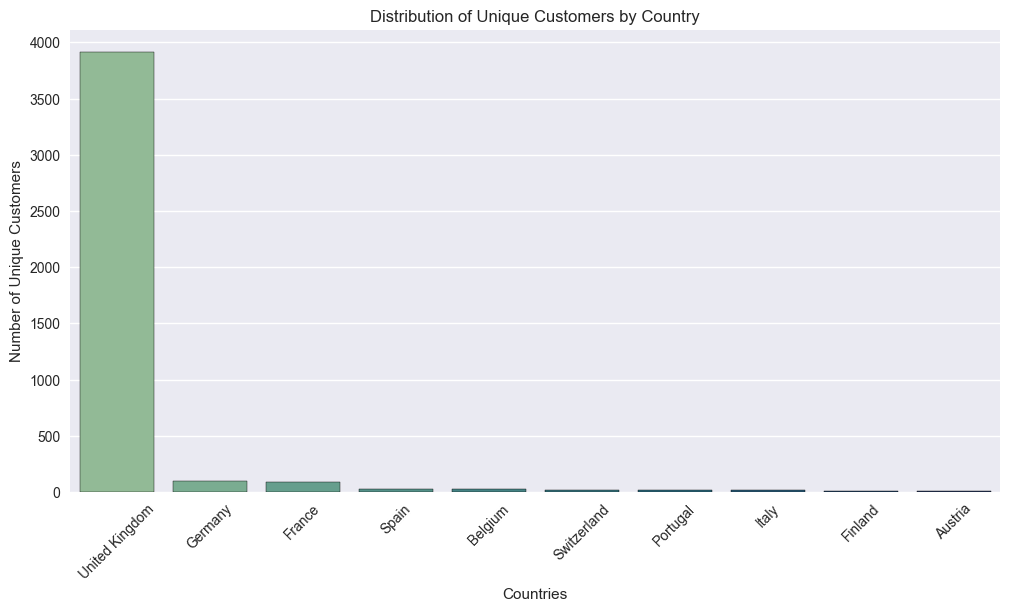

In [31]:
# Identify the countries of customers and highlight the top 10

bardata = data_clean.groupby('Country', as_index=False)['CustomerID'].nunique().sort_values(by='CustomerID', ascending=False).head(10)

fig = plt.figure(figsize=(12,6))
sns.barplot(
    data=bardata,
    x='Country',
    y='CustomerID',
    hue='Country',
    legend=False,
    palette='crest'
)

plt.title('Distribution of Unique Customers by Country')
plt.ylabel('Number of Unique Customers')
plt.xlabel('Countries')
plt.xticks(rotation=45)
plt.show();

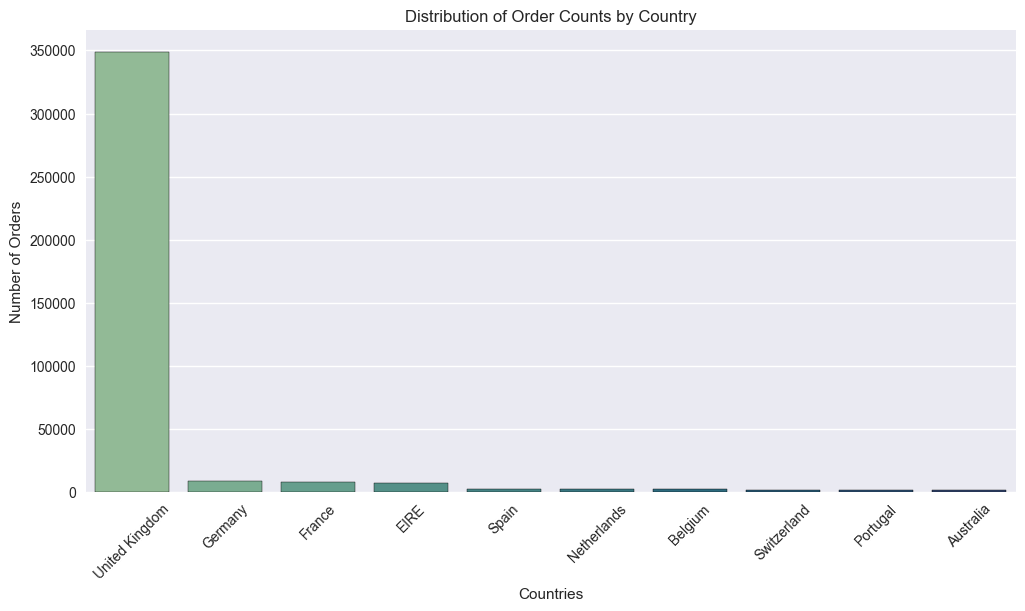

In [32]:
# Visualize the top 10 countries by number of orders

bardata = data_clean.groupby('Country', as_index=False)['InvoiceNo'].count().sort_values(by='InvoiceNo', ascending=False).head(10)

fig = plt.figure(figsize=(12,6))
sns.barplot(
    data=bardata,
    x='Country',
    y='InvoiceNo',
    hue='Country',
    legend=False,
    palette='crest'
)

plt.title('Distribution of Order Counts by Country')
plt.ylabel('Number of Orders')
plt.xlabel('Countries')
plt.xticks(rotation=45)
plt.show();

In [33]:
# Add a TotalPrice column for the total order price

data_clean['Total_Price'] = data_clean['UnitPrice'] * (data_clean['Quantity'] - data_clean['QuantityCanceled'])
total_price_mean = data_clean['Total_Price'].mean()
print(f'Average total order value: {total_price_mean:.0f} pounds sterling')

Average total order value: 21 pounds sterling


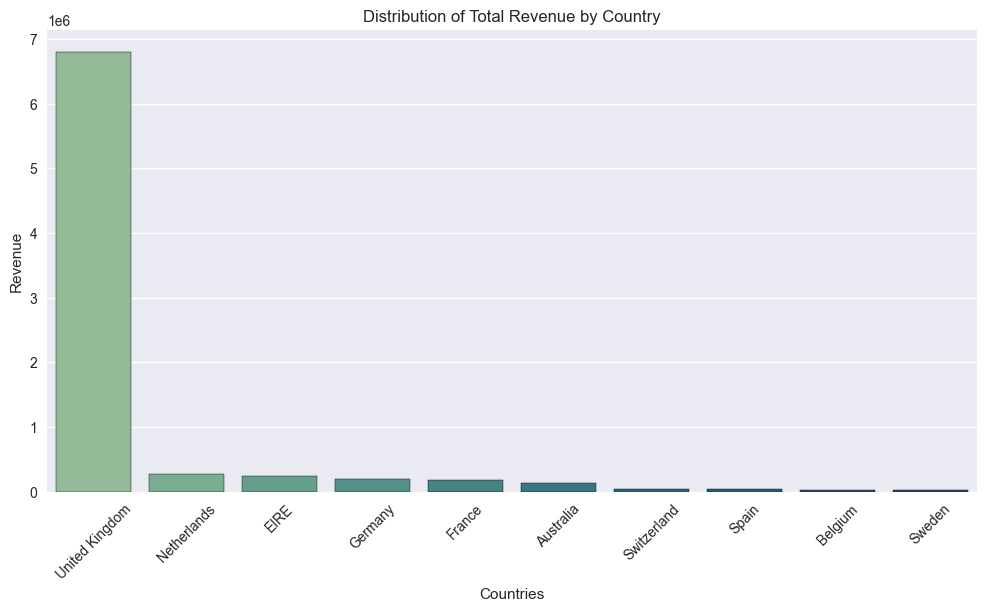

In [34]:
# Visualize the top 10 countries by total revenue

bardata = data_clean.groupby('Country', as_index=False)['Total_Price'].sum().sort_values(by='Total_Price', ascending=False).head(10)

fig = plt.figure(figsize=(12,6))
sns.barplot(
    data=bardata,
    x='Country',
    y='Total_Price',
    hue='Country',
    legend=False,
    palette='crest'
)

plt.title('Distribution of Total Revenue by Country')
plt.ylabel('Revenue')
plt.xlabel('Countries')
plt.xticks(rotation=45)
plt.show();

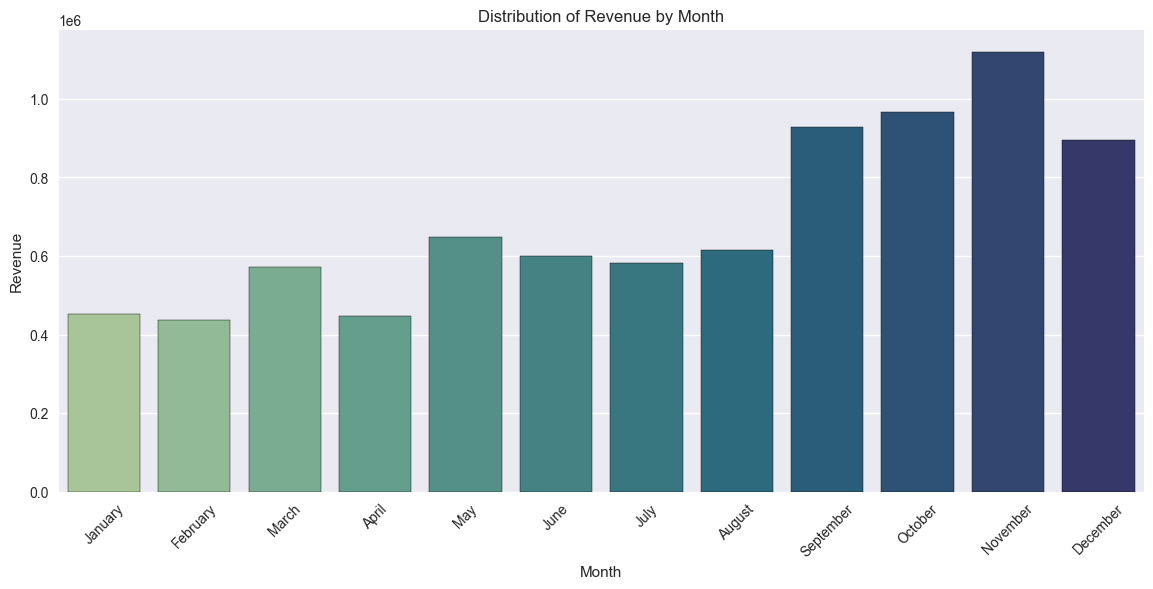

In [35]:
# Visualize the distribution of total revenue by month

bardata = data_clean.groupby('Month', as_index=False)['Total_Price'].sum()

fig = plt.figure(figsize=(14,6))
sns.barplot(
    data=bardata,
    x='Month',
    y='Total_Price',
    hue='Month',
    legend=False,
    palette='crest',
    
)

plt.title('Distribution of Revenue by Month')
plt.ylabel('Revenue')
plt.xlabel('Month')
plt.xticks(
    ticks=range(12),
    rotation=45, 
    labels=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'],
)
plt.show();

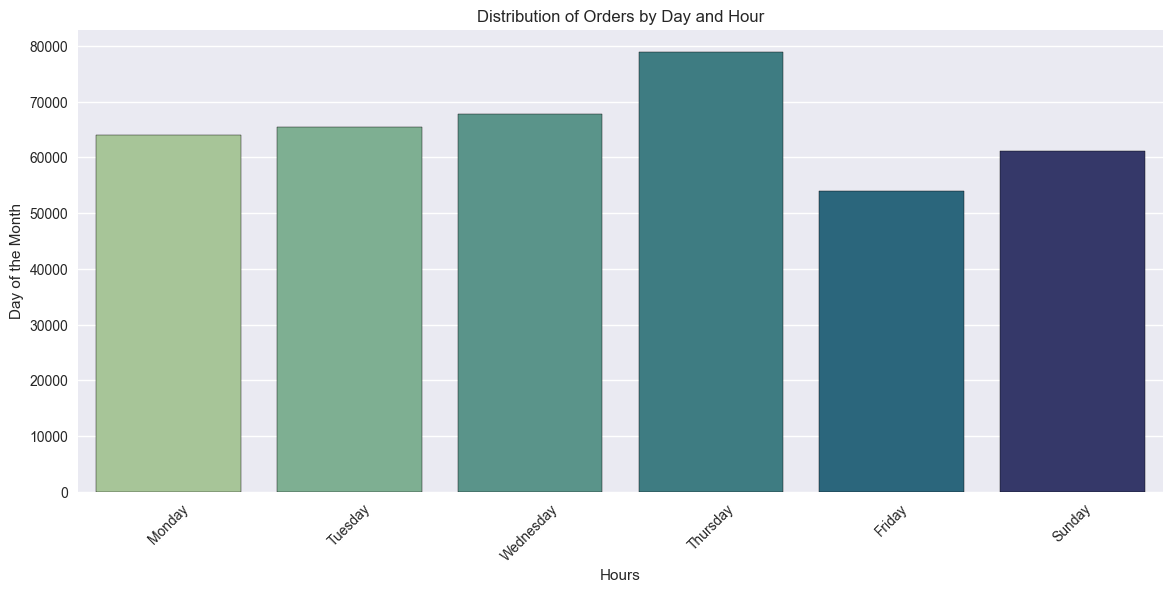

In [36]:
# Verify order counts by day of the week

weekday_data = data_clean.groupby('Day_of_week', as_index=False)['InvoiceNo'].count()

fig = plt.figure(figsize=(14,6))
sns.barplot(
    data=weekday_data,
    x='Day_of_week',
    y='InvoiceNo',
    hue='Day_of_week',
    legend=False,
    palette='crest'
)

plt.title('Distribution of Orders by Day and Hour')
plt.xlabel('Hours')
plt.ylabel('Day of the Month')
plt.xticks(
    ticks=range(6),
    rotation=45,
    labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
)
plt.show();

In [37]:
# confirming no data for Saturday

weekday_data.value_counts()

Day_of_week  InvoiceNo
0            63963        1
1            65491        1
2            67769        1
3            78904        1
4            53939        1
6            61084        1
Name: count, dtype: int64

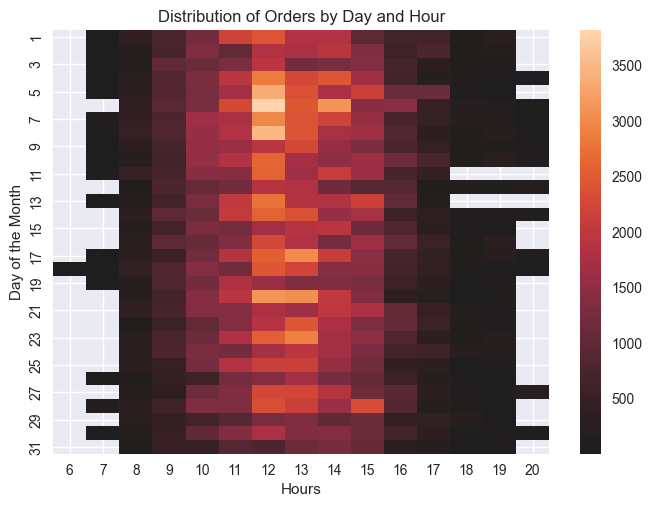

In [38]:
# Visualize the average daily order counts by time of day

pivot = pd.pivot_table(
    data_clean,
    values='InvoiceNo',
    index='Date',
    columns='Hour',
    aggfunc='count'
)

sns.heatmap(pivot, center=True)
plt.title('Distribution of Orders by Day and Hour')
plt.xlabel('Hours')
plt.ylabel('Day of the Month')
plt.show();

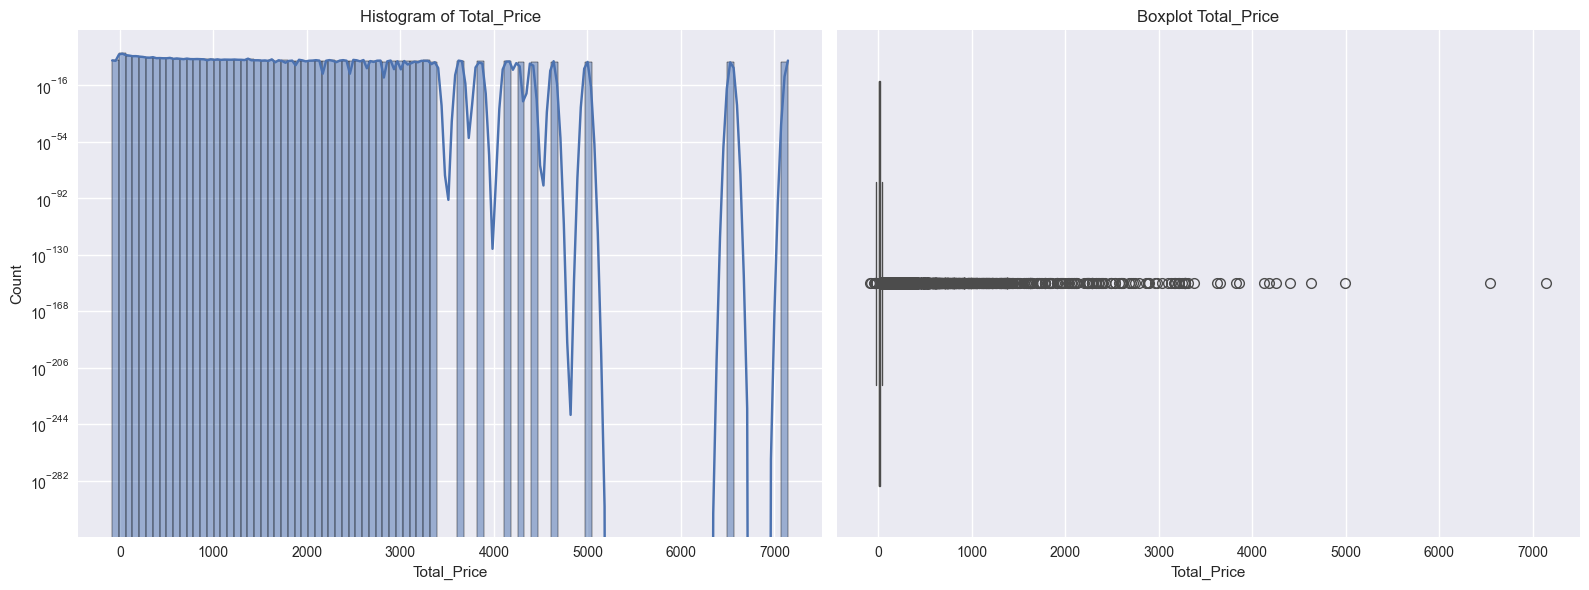

In [39]:
# Check for outliers

fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,6))
sns.histplot(
    data_clean['Total_Price'], 
    bins=100, 
    kde=True, 
    ax=axes[0]
)
axes[0].set_title('Histogram of Total_Price')
axes[0].set_xlabel('Total_Price')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')

sns.boxplot(
    x=data_clean['Total_Price'], 
    ax=axes[1]
)
axes[1].set_title('Boxplot Total_Price')
axes[1].set_xlabel('Total_Price')

plt.tight_layout()
plt.show();

### **EDA Conclusions**:

* The majority of orders, revenue, and unique customers come from the United Kingdom.

* Order volume peaks toward the end of the year, likely due to pre-Christmas demand.

* No orders are recorded on Saturdays; Thursdays see the highest order volume.

* Orders primarily occur between 10 AM and 3 PM.

* Outliers in revenue exist and will be addressed later.


## 4. RFM Customer Segmentation

### 4.1 Creating the RFM Table and Applying PCA

We will create features for customer segmentation using the RFM (`Recency`, `Frequency`, `Monetary`) method, which groups customers based on:

* `Recency`: Time since the customer’s last purchase.
* `Frequency`: Total number of customer purchases.
* `Monetary Value`: Total amount spent by the customer.

RFM analysis divides customers into groups based on how recently they purchased, how often, and how much they spent.

We will create the `RFM table` by grouping data by `CustomerID` and calculating:

* `Recency` Difference in days between the reference date and the customer’s last order::
    $$t_0-max(t_{i1}, t_{i2},..., t_{iM})$$

    where $t_{ij}$ — is the date and time of the i-th customer’s j-th purchase.

    The reference date $t_0$ is set to December 10, 2011 (datetime — '2011-12-10 00:00:00'), one day after the latest data.

* `Frequency` Total number of unique orders by the i-th customer.
* `Monetary Value` Total amount spent by the i-th customer, accounting for returns.

In [40]:
# Create the RFM table

# Set the reference date

reference_date = pd.to_datetime('2011-12-10 00:00:00')

# Group by customer

rfm_table = data_clean.groupby('CustomerID').agg({
    'InvoiceDate' : lambda x: (reference_date - x.max()).days,
    'InvoiceNo' : 'nunique',
    'Total_Price' : 'sum'
}).reset_index()

rfm_table.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm_table.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,325,1,0.00
1,12347,2,7,4310.00
2,12348,75,4,1437.24
3,12349,18,1,1457.55
4,12350,310,1,294.40


In [41]:
# Examine some characteristics

print(f'Number of customers with purchases over 200 days ago: {rfm_table[rfm_table["Recency"] > 200]["CustomerID"].count()}')
print(f'On average, customers place {rfm_table["Frequency"].mean():.0f} orders')
print(f'Customer ID 12360 spent {rfm_table[rfm_table["CustomerID"] == "12360"]["Monetary"].sum():.0f} pounds sterling')

Number of customers with purchases over 200 days ago: 743
On average, customers place 4 orders
Customer ID 12360 spent 2302 pounds sterling


In [42]:
# Display boxplots for each feature

fig = make_subplots(rows=1, cols=3, subplot_titles=["Recency", "Frequency", "Monetary"])

# Add boxplots manually

fig.add_trace(go.Box(x=rfm_table['Recency'], name='Recency'), row=1, col=1)
fig.add_trace(go.Box(x=rfm_table['Frequency'], name='Frequency'), row=1, col=2)
fig.add_trace(go.Box(x=rfm_table['Monetary'], name='Monetary'), row=1, col=3)

fig.update_layout(height=400, width=1000, title_text="Boxplots for RFM Metrics")

#fig.write_html('plotly/boxplot_1.html')
fig.show();

We previously observed `outliers`, including customers with **over 100 orders** and **total order values exceeding 190,000 pounds sterling**.

To improve clustering quality without losing too much data, we will remove outliers by setting an upper bound at the **95th percentile** for `Frequency` and `Monetary`.


In [43]:
# Define the upper bound and filter the table

frequency_95 = np.quantile(rfm_table['Frequency'], 0.95)
monetary_95 = np.quantile(rfm_table['Monetary'], 0.95)

rfm_table_cleaned = rfm_table[~((rfm_table['Frequency'] > frequency_95) | (rfm_table['Monetary'] > monetary_95))]
print(f'rfm_table shape after cleaning outliers {rfm_table_cleaned.shape}')

rfm_table shape after cleaning outliers (4044, 4)


In [44]:
# Check the updated distributions

fig = make_subplots(rows=1, cols=3, subplot_titles=["Recency", "Frequency", "Monetary"])

fig.add_trace(go.Box(x=rfm_table_cleaned['Recency'], name='Recency'), row=1, col=1)
fig.add_trace(go.Box(x=rfm_table_cleaned['Frequency'], name='Frequency'), row=1, col=2)
fig.add_trace(go.Box(x=rfm_table_cleaned['Monetary'], name='Monetary'), row=1, col=3)

fig.update_layout(height=400, width=1000, title_text="Boxplots for RFM Metrics")

#fig.write_html('plotly/boxplot_2.html')
fig.show();

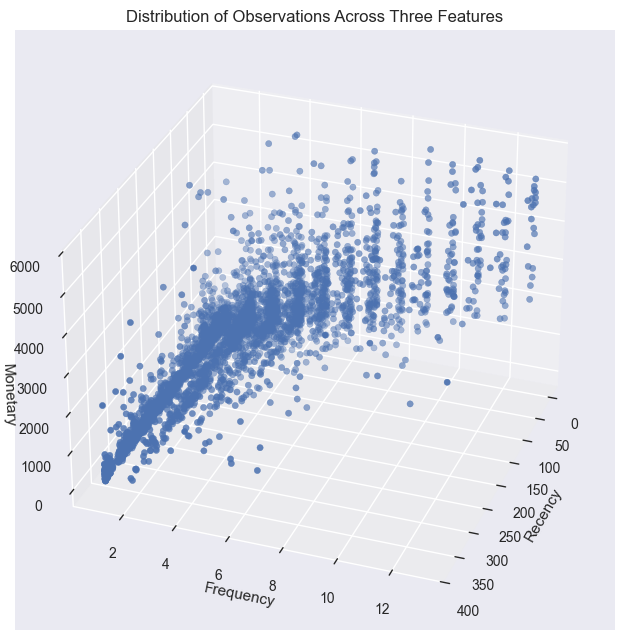

In [45]:
# Visualize the three-dimensional feature space to assess observation distribution
# Create a 3D object

fig = plt.figure(figsize=(6,6))
ax = Axes3D(fig)

# Add an additional axis to the figure

fig.add_axes(ax)
ax.azim = 20
ax.elev = 30

# Visualize the data, passing x, y, z values and color grouping

ax.scatter(
    rfm_table_cleaned['Recency'].to_list(), 
    rfm_table_cleaned['Frequency'].to_list(),
    rfm_table_cleaned['Monetary'].to_list()
)

# добавим оси
ax.set_title('Distribution of Observations Across Three Features')
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary');
#experiment.log_figure('Distribution of Observations Across Three Features', plt)
plt.show();

The visualization shows no clear clustering structure. Customers with high `Monetary` and `Frequency` values are likely top customers, but the overall point cloud is difficult to segment.

We will apply dimensionality reduction techniques, starting with `Principal Component Analysis (PCA)`. To ensure stable PCA performance, **we will standardize the data** and **wrap preprocessing steps in a** `pipeline`.

In [46]:
# Create a transformer for standardizing relevant columns

ct = compose.make_column_transformer(
    (preprocessing.StandardScaler(), ['Recency', 'Frequency', 'Monetary']),
    remainder='drop'
)

# Pipeline: scaling + PCA

pipeline_pca = pipeline.Pipeline([
    ('ct', ct),
    ('pca', decomposition.PCA(n_components=2))
])

pipeline_pca.fit(rfm_table_cleaned)

# Examine the explained variance ratios after PCA

explained_var = pipeline_pca.named_steps['pca'].explained_variance_ratio_
print(f'Explained variance ratio for the first component: {explained_var[0]:.2%}, second component: {explained_var[1]:.2%}')


Explained variance ratio for the first component: 67.75%, second component: 24.01%


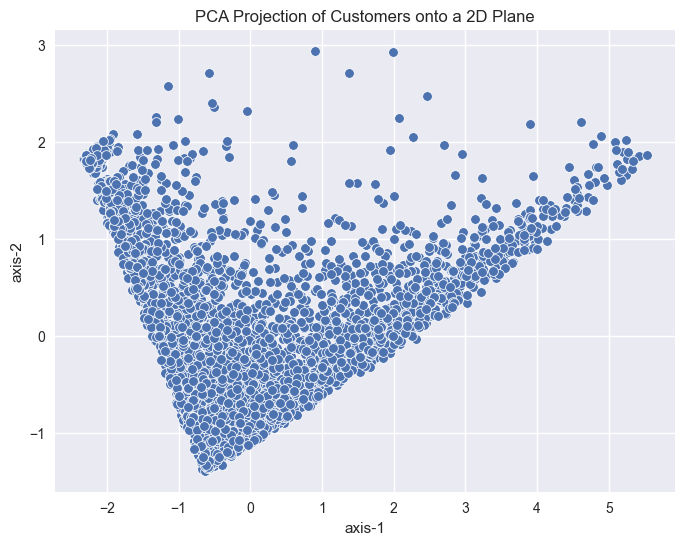

In [47]:
# Visualize the PCA-projected space

rfm_table_processed = pipeline_pca.fit_transform(rfm_table_cleaned)
rfm_table_processed = pd.DataFrame(rfm_table_processed, columns=['axis-1', 'axis-2'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=rfm_table_processed, x='axis-1', y='axis-2', ax=ax)
plt.title('PCA Projection of Customers onto a 2D Plane')

#experiment.log_figure('PCA Projection of Customers onto a 2D Plane', plt)
plt.show();

**To segment the PCA space, we will create a function to find the optimal number of clusters**

In [48]:
# Create a function to find the optimal number of clusters

def get_silhouette(cluster_num, model_type, X):
    """Takes the number of clusters, model, and clustering sample as input and returns silhouette coefficients for each cluster count.
        Additionally, visualizes the silhouette coefficients. Includes all models used in the project.

    Args:
        cluster_num (int): Number of clusters to evaluate
        X (pd.DataFrame): Sample for training the model
    """
    silhouette_scores = []
    
    # Train the model with the specified number of clusters and record the silhouette coefficient
    
    if model_type == cluster.KMeans:
        for i in range(2, cluster_num):
            model = model_type(
                random_state=42,
                n_clusters=i
            )
            clusters = model.fit_predict(X)
            silhouette = round(metrics.silhouette_score(X, clusters),4)
            silhouette_scores.append(silhouette)
            print(f'For cluster {i}, silhouette coefficient: {silhouette:.3f}')
    elif model_type == mixture.GaussianMixture:
        for i in range(2, cluster_num):
            model = model_type(
                random_state=42,
                n_components=i
            )
            clusters = model.fit_predict(X)
            silhouette = round(metrics.silhouette_score(X, clusters),4)
            silhouette_scores.append(silhouette)
            print(f'For cluster {i}, silhouette coefficient: {silhouette:.3f}')
    elif model_type == cluster.AgglomerativeClustering:
        for i in range(2, cluster_num):
            model = model_type(
                n_clusters=i
            )
            clusters = model.fit_predict(X)
            silhouette = round(metrics.silhouette_score(X, clusters),4)
            silhouette_scores.append(silhouette)
            print(f'For cluster {i}, silhouette coefficient: {silhouette:.3f}')
    
    cluster_range = range(2, cluster_num)
    
    # Visualize the silhouette coefficient distribution
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.lineplot(
        x=cluster_range,
        y=silhouette_scores,
        markers='o',
        ax=ax
    )
    plt.title(f'Silhouette Score per Cluster for {model_type} Algorithm')
    plt.xlabel('Cluster')
    plt.ylabel('Silhouette score')
    plt.grid(True)
    #experiment.log_figure(f'Silhouette Score per Cluster for {model_type} Algorithm', plt)
    plt.show();

We will use the `K-Means` algorithm to find the optimal number of `clusters` (2 to 10) based on the silhouette coefficient, with `random_state=42` and default parameters.

For cluster 2, silhouette coefficient: 0.500
For cluster 3, silhouette coefficient: 0.524
For cluster 4, silhouette coefficient: 0.498
For cluster 5, silhouette coefficient: 0.449
For cluster 6, silhouette coefficient: 0.448
For cluster 7, silhouette coefficient: 0.446
For cluster 8, silhouette coefficient: 0.424
For cluster 9, silhouette coefficient: 0.422


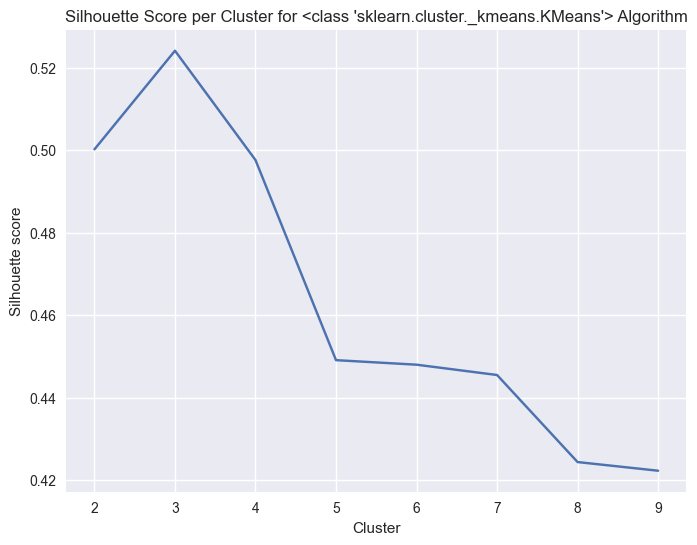


Time spent on parameter tuning: 7.24 seconds


In [49]:
# Find the optimal number of clusters for KMeans

start_time = time.time()

get_silhouette(10, cluster.KMeans, rfm_table_processed)

print()
print(f'Time spent on parameter tuning: {time.time() - start_time:.2f} seconds')

Next, we will use the `EM algorithm (GaussianMixture)` to find the optimal number of `clusters` (2 to 10) based on the silhouette coefficient, with `random_state=42` and default parameters.

For cluster 2, silhouette coefficient: 0.343
For cluster 3, silhouette coefficient: 0.436
For cluster 4, silhouette coefficient: 0.350
For cluster 5, silhouette coefficient: 0.280
For cluster 6, silhouette coefficient: 0.273
For cluster 7, silhouette coefficient: 0.237
For cluster 8, silhouette coefficient: 0.195
For cluster 9, silhouette coefficient: 0.162


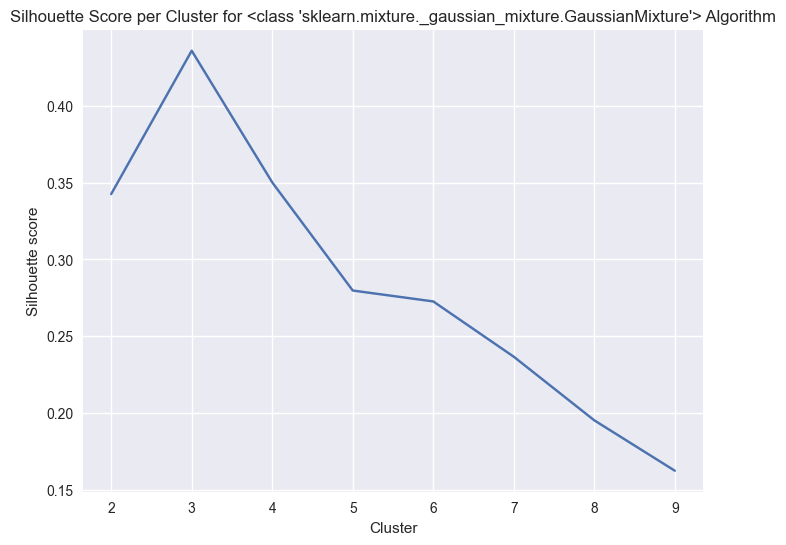


Time spent on parameter tuning: 7.61 seconds


In [50]:
# Find the optimal number of clusters for GaussianMixture

start_time = time.time()

get_silhouette(10, mixture.GaussianMixture, rfm_table_processed)

print()
print(f'Time spent on parameter tuning: {time.time() - start_time:.2f} seconds')

We will train a model with the optimal number of clusters on the `PCA-decomposed` data using `K-Means`, as it showed better performance.

In [51]:
# Use KMeans for clustering, as it demonstrated higher efficiency

model = cluster.KMeans(random_state=42, n_clusters=3)
labels = model.fit_predict(rfm_table_processed)

counted_clusters = Counter(labels)
print(f'Number of samples per cluster:\n{counted_clusters}')

Number of samples per cluster:
Counter({2: 2270, 1: 1001, 0: 773})


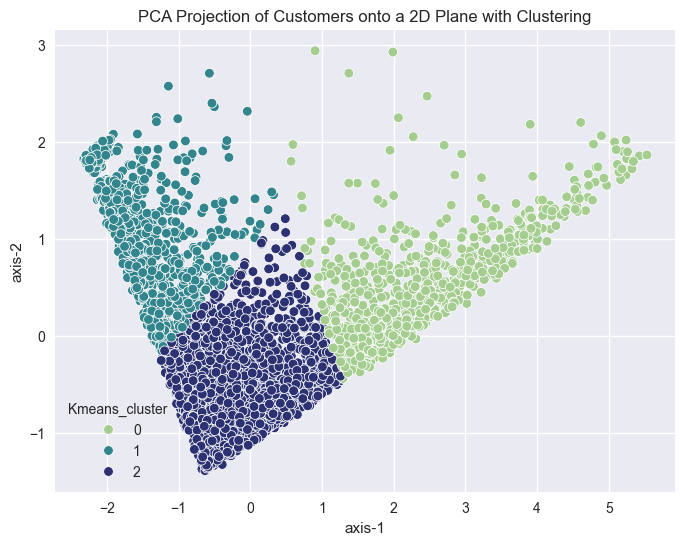

In [52]:
# Visualize clustering results

rfm_table_clustered = pd.DataFrame(rfm_table_processed, columns=['axis-1', 'axis-2'])
rfm_table_clustered['Kmeans_cluster'] = labels

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=rfm_table_clustered, x='axis-1', y='axis-2', hue='Kmeans_cluster', palette='crest', ax=ax)
plt.title('PCA Projection of Customers onto a 2D Plane with Clustering')
#experiment.log_figure('PCA Projection of Customers onto a 2D Plane with Clustering')
plt.show();

To profile the clusters, we will map the clusters back to the outlier-cleaned RFM table, group by cluster, and calculate the mean for each feature.

In [53]:
# Assign clusters to the data

rfm_table_cleaned['Kmeans_cluster'] = labels

# Calculate the mean Frequency by cluster

mean_freq = rfm_table_cleaned.groupby('Kmeans_cluster', as_index=False)['Frequency'].mean().round(2)
display(mean_freq)

,Kmeans_cluster,Frequency
0,0,7.08
1,1,1.41
2,2,2.33


### We will profile these segments using a Polar Diagram

We will use a Radar Chart (polar diagram) to visualize cluster profiles, displaying multiple equivalent categories as a "web." Using the `plotly.graph_objects` module’s `Scatterpolar` function, we implemented `plot_cluster_profile()`, which visualizes each cluster’s profile. The function takes two parameters: `grouped_data` (cluster-grouped customer characteristics) and `n_clusters` (number of clusters).

To use the polar diagram, all features must be normalized to a 0–1 scale, with 1 as the maximum and 0 as the minimum. This normalization is included in `plot_cluster_profile()`.

In [54]:
# Define the function

def plot_cluster_profile(grouped_data, n_clusters):
    """Visualizes each cluster’s profile as a polar diagram.

    Args:
        grouped_data (pd.DataFrame): Cluster-grouped data
        n_clusters (int): Number of clusters in the data
    """
    # Normalize grouped data to a 0–1 scale
    scaler = preprocessing.MinMaxScaler()
    grouped_data = pd.DataFrame(scaler.fit_transform(grouped_data), columns=grouped_data.columns)
    # List features
    features = grouped_data.columns
    # Create an empty figure
    fig = go.Figure()
    # Visualize a polar diagram for each cluster
    for i in range(n_clusters):
        # Add a polar diagram to the figure
        fig.add_trace(go.Scatterpolar(
            r=grouped_data.iloc[i].values,  # Radii
            theta=features,  # Tick labels
            fill='toself',  # Fill the polygon
            name=f'Cluster {i}',  # Cluster label
        ))
    # Update figure layout
    fig.update_layout(
        showlegend=True,  # Show legend
        autosize=False,  # Set custom size
        width=800,  # Width (pixels)
        height=800,  # Height (pixels)
    )
    # Display the figure
    fig.show()

In [55]:
# Visualize cluster profiles as a polar diagram based on mean RFM characteristics

grouped_data = rfm_table_cleaned.groupby('Kmeans_cluster')[['Recency', 'Frequency', 'Monetary']].mean()
plot_cluster_profile(grouped_data, 3)

### **Cluster Descriptions:**

* `Cluster 0`: "Loyal" customers with the highest revenue, most frequent purchases, and most recent activity.

* `Cluster 2`: "Intermediate" customers who are active but purchase less frequently and spend less than loyal customers, yet are not "churned."

* `Cluster 1`: "Churned" customers who spent the least and made their last purchase long ago.

### 4.2 RFM Customer Segmentation: Using t-SNE and Clustering

We will transform the outlier-cleaned RFM table into a two-dimensional representation using `t-SNE`, with feature scaling. We will create a `pipeline` with:

Standardization using `StandardScaler` (default parameters).
`t-SNE` with two components, `perplexity=50`, and `random_state=100`.

We will train the `pipeline` on the outlier-cleaned RFM table and apply the transformation.

In [56]:
# Transform the outlier-cleaned RFM table using t-SNE

ct = compose.make_column_transformer(
    (preprocessing.StandardScaler(), ['Recency', 'Frequency', 'Monetary']),
    remainder='drop'
)

t_sne_pipeline = pipeline.Pipeline([
    ('ct', ct),
    ('t_sne', manifold.TSNE(perplexity=50, random_state=100))
])

rfm_tsne = t_sne_pipeline.fit_transform(rfm_table_cleaned)

# Check the Kullback-Leibler divergence for the trained t-SNE algorithm

kl_divergence = t_sne_pipeline.named_steps['t_sne'].kl_divergence_
print(f'Kullback-Leibler divergence for the trained t-SNE algorithm: {kl_divergence:.3f}')

Kullback-Leibler divergence for the trained t-SNE algorithm: 0.542


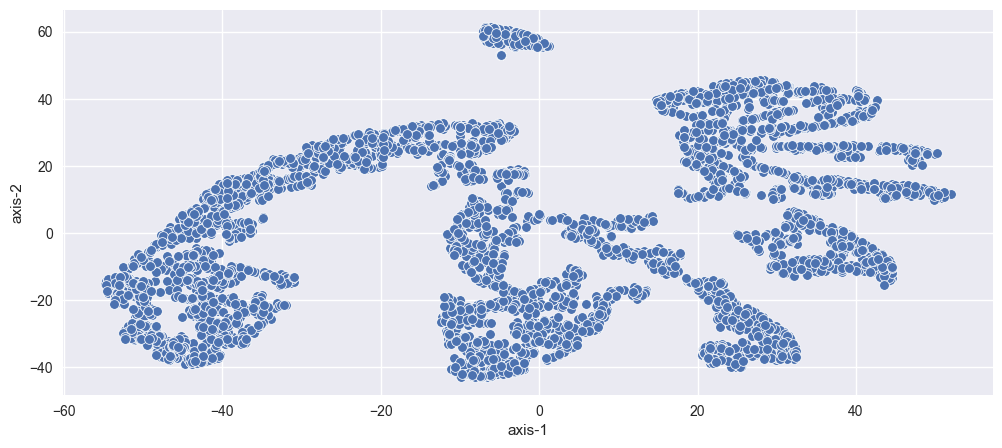

In [57]:
# Visualize the t-SNE-decomposed space

fig = plt.figure(figsize=(12, 5))

plotdata = pd.DataFrame(rfm_tsne, columns=['axis-1', 'axis-2'])
sns.scatterplot(data=plotdata, x='axis-1', y='axis-2')
#experiment.log_figure('t-SNE-decomposed space', plt)
plt.show();

We will apply clustering algorithms to form new customer segments, starting with` K-Means`. We will find the optimal number of `clusters` (3 to 8) based on the silhouette coefficient, with `random_state=42` and default parameters.

For cluster 2, silhouette coefficient: 0.401
For cluster 3, silhouette coefficient: 0.429
For cluster 4, silhouette coefficient: 0.479
For cluster 5, silhouette coefficient: 0.478
For cluster 6, silhouette coefficient: 0.460
For cluster 7, silhouette coefficient: 0.477
For cluster 8, silhouette coefficient: 0.482


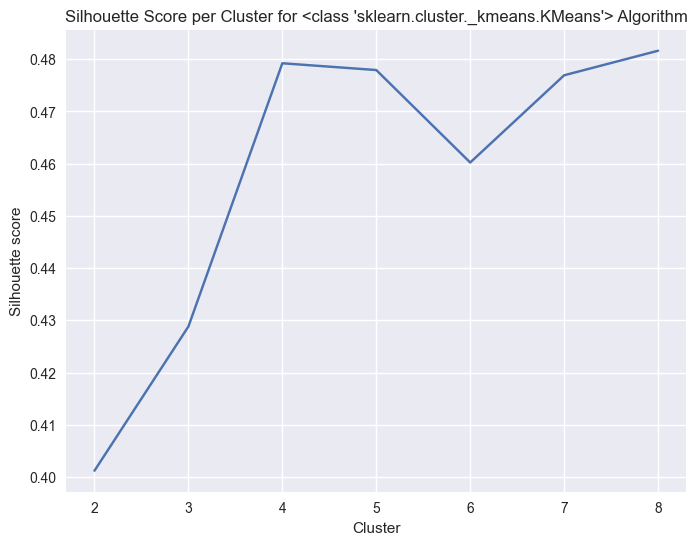


Time spent on parameter tuning: 6.21 seconds


In [58]:
# Find the optimal number of clusters for KMeans

start_time = time.time()

get_silhouette(9, cluster.KMeans, rfm_tsne)

print()
print(f'Time spent on parameter tuning: {time.time() - start_time:.2f} seconds')

Next, we will use the `EM algorithm` (GaussianMixture) to find the optimal number of `clusters` (3 to 8) based on the silhouette coefficient, with `random_state=42` and default parameters.

For cluster 2, silhouette coefficient: 0.405
For cluster 3, silhouette coefficient: 0.427
For cluster 4, silhouette coefficient: 0.469
For cluster 5, silhouette coefficient: 0.390
For cluster 6, silhouette coefficient: 0.385
For cluster 7, silhouette coefficient: 0.449
For cluster 8, silhouette coefficient: 0.385


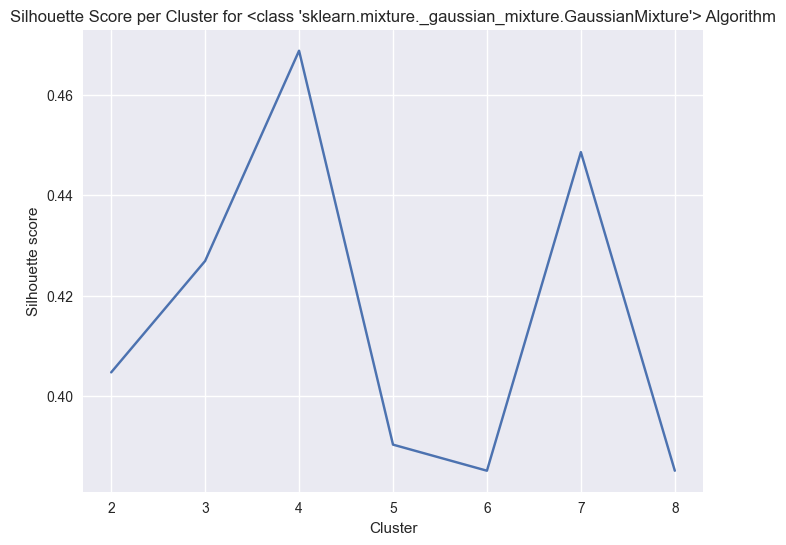


Time spent on parameter tuning: 6.73 seconds


In [59]:
# Find the optimal number of clusters for GaussianMixture

start_time = time.time()

get_silhouette(9, mixture.GaussianMixture, rfm_tsne)

print()
print(f'Time spent on parameter tuning: {time.time() - start_time:.2f} seconds')

We will use `Agglomerative Clustering` to find the optimal number of `clusters` (2 to 8) based on the silhouette coefficient, with default parameters except for the number of clusters.

For cluster 2, silhouette coefficient: 0.380
For cluster 3, silhouette coefficient: 0.423
For cluster 4, silhouette coefficient: 0.457
For cluster 5, silhouette coefficient: 0.470
For cluster 6, silhouette coefficient: 0.469
For cluster 7, silhouette coefficient: 0.459
For cluster 8, silhouette coefficient: 0.479


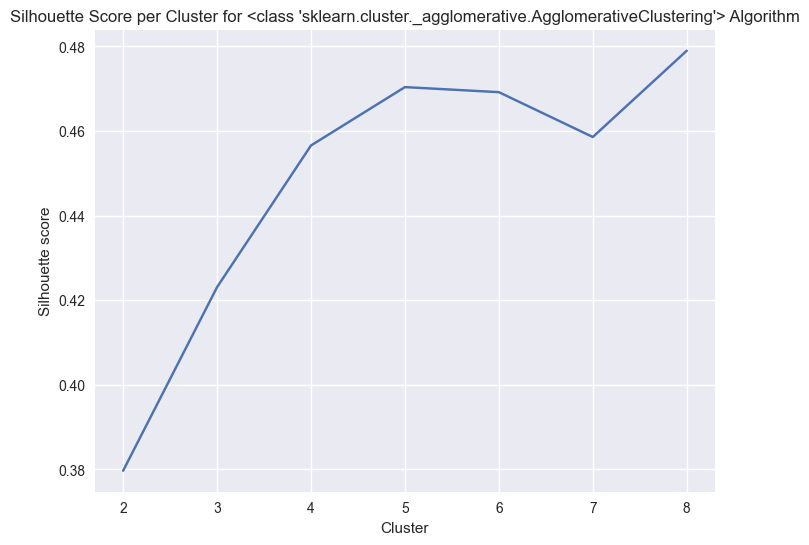


Time spent on parameter tuning: 3.11 seconds


In [60]:
# Find the optimal number of clusters for AgglomerativeClustering

start_time = time.time()

get_silhouette(9, cluster.AgglomerativeClustering, rfm_tsne)

print()
print(f'Time spent on parameter tuning: {time.time() - start_time:.2f} seconds')

We will use `K-Means` for clustering, as it performed slightly better, training the model with the optimal number of clusters on the `t-SNE-decomposed data`.

In [61]:
# Train the best model with the previously selected number of clusters

model = cluster.KMeans(random_state=42, n_clusters=8)
clusters_tsne = model.fit_predict(rfm_tsne)

counted_tsne = Counter(clusters_tsne)
print(f'Number of samples per cluster:\n{counted_tsne}')

Number of samples per cluster:
Counter({0: 688, 3: 656, 5: 539, 4: 538, 1: 464, 7: 405, 6: 399, 2: 355})


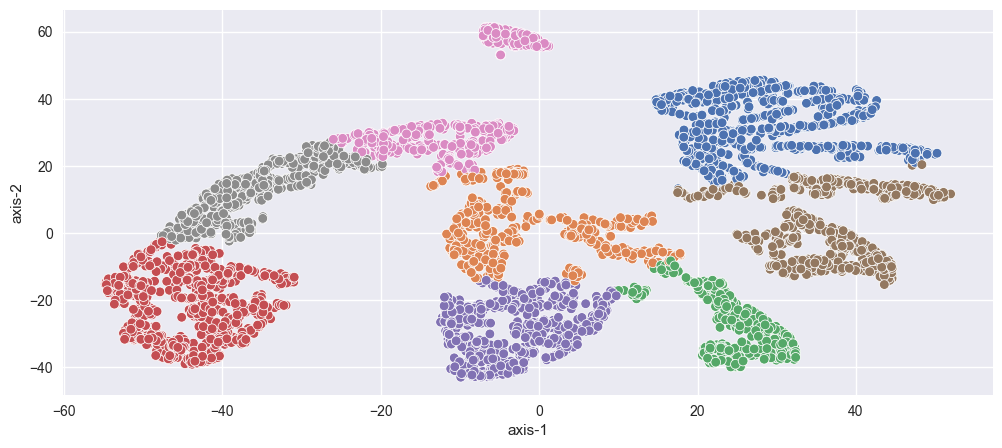

In [62]:
# Visualize clustering results

fig = plt.figure(figsize=(12, 5))

plotdata = pd.DataFrame(rfm_tsne, columns=['axis-1', 'axis-2'])
plotdata['clusters'] = clusters_tsne

sns.scatterplot(data=plotdata, x='axis-1', y='axis-2', hue='clusters', palette='deep', legend=False)
#experiment.log_figure('t-SNE-decomposed space with 8 clusters', plt)
plt.show();

**We have identified 8 customer segments**. Let’s profile these segments.

To profile the clusters, we will map the clusters back to the outlier-cleaned RFM table.

In [63]:
# Add clusters to the RFM table

rfm_table_cleaned['tsne_clusters'] = clusters_tsne

# Calculate the mean Recency by cluster

mean_rec = rfm_table_cleaned.groupby('tsne_clusters', as_index=False)['Recency'].mean().round(2)
display(mean_rec)

,tsne_clusters,Recency
0,0,27.24
1,1,191.57
2,2,34.70
3,3,46.33
4,4,39.81
5,5,44.74
6,6,312.96
7,7,181.44


In [64]:
# Visualize clusters using our function

grouped_data = rfm_table_cleaned.groupby('tsne_clusters')[['Recency', 'Frequency', 'Monetary']].mean()
plot_cluster_profile(grouped_data, 8)

## 5. RFM Clustering: Classifying New Customers into Clusters

We built a clustering model for a subset of customers. How can we predict the segment for customers not included in the training set?

We will transform the clustering task into a `classification task`. With true cluster labels and RFM characteristics, we will train a model to predict customer segments based on RFM features.

In [65]:
# Split the table into training and test sets

X = rfm_table_cleaned.drop(['CustomerID','Kmeans_cluster', 'tsne_clusters'], axis=1)
y = rfm_table_cleaned['tsne_clusters']

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
print(f'Train set dimension: {X_train.shape}')
print(f'Test set dimension: {X_test.shape}')

Train set dimension: (3235, 3)
Test set dimension: (809, 3)


We will build multiple models and select the best one, avoiding linear methods due to the non-linear nature of `t-SNE`. We will use ensemble classification algorithms.

Starting with Random Forest, we will use `GridSearchCV` to tune parameters on the following grid:

```
param_grid = {
    'max_depth': range(5, 15),
    'criterion': ['gini', 'entropy'],
    'n_estimators': [100, 200, 500]
}
```

We will use `random_state=42` for the `RandomForestClassifier`, `accuracy` as the metric, and `5-fold cross-validation`.

In [67]:
# Tune parameters for RandomForestClassifier using GridSearchCV

start_time = time.time()

param_grid = {
    'max_depth': range(5, 15),
    'criterion': ['gini', 'entropy'],
    'n_estimators': [100, 200, 500]
}

gridsearch_rf = model_selection.GridSearchCV(
    param_grid=param_grid,
    estimator=ensemble.RandomForestClassifier(random_state=42),
    n_jobs=-1,
    scoring='accuracy',
    cv=5,
    verbose=True
)


gridsearch_rf.fit(X_train, y_train)

print(f'Time spent on model training and hyperparameter tuning: {time.time() - start_time:.2f} seconds')
print()
print(f'Optimal hyperparameters:\n{gridsearch_rf.best_params_}')

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Time spent on model training and hyperparameter tuning: 58.23 seconds

Optimal hyperparameters:
{'criterion': 'gini', 'max_depth': 12, 'n_estimators': 100}


In [68]:
# Train the model with the best hyperparameters and record accuracy

clf_rf = gridsearch_rf.best_estimator_
clf_rf.fit(X_train, y_train)

y_pred_rf = clf_rf.predict(X_test)
score_rf = metrics.accuracy_score(y_test, y_pred_rf)

#experiment.log_metric('Accuracy', score_rf)
print(f'Accuracy score for test sample: {score_rf:.3f}')

Accuracy score for test sample: 0.977


The accuracy is high but not perfect. We will try to improve it using boosting.

We will use `GridSearchCV` to tune parameters for `GradientBoostingClassifier` on the following grid:

```
param_grid = {
    'max_depth': range(3, 7),
    'learning_rate': [0.001, 0.01, 0.1],
    'n_estimators': [100, 200, 500]
}
```

We will use `random_state=42`, `accuracy` as the metric, and `5-fold cross-validation`

In [69]:
# Tune parameters for GradientBoostingClassifier using GridSearchCV

start_time = time.time()

param_grid = {
    'max_depth': range(3, 7),
    'learning_rate': [0.001, 0.01, 0.1],
    'n_estimators': [100, 200, 500]
}

gridsearch_gb = model_selection.GridSearchCV(
    param_grid=param_grid,
    estimator=ensemble.GradientBoostingClassifier(random_state=42),
    n_jobs=-1,
    scoring='accuracy',
    cv=5,
    verbose=True
)

gridsearch_gb.fit(X_train, y_train)

print(f'Time spent on model training and hyperparameter tuning: {time.time() - start_time:.2f} seconds')
print()
print(f'Optimal hyperparameters:\n{gridsearch_gb.best_params_}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Time spent on model training and hyperparameter tuning: 328.77 seconds

Optimal hyperparameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500}


In [70]:
# Train the model with the best hyperparameters and record accuracy

clf_gb = gridsearch_gb.best_estimator_
clf_gb.fit(X_train, y_train)

y_pred_gb = clf_gb.predict(X_test)
score_gbclf = metrics.accuracy_score(y_test, y_pred_gb)

#experiment.log_metric('Accuracy', score_gbclf)
print(f'Accuracy score for test sample: {score_gbclf:.3f}')

Accuracy score for test sample: 0.977


We will try `XGBoost` with default parameters and `random_state=42`

In [71]:
# Train the XGBoost algorithm

xgb_clf = XGBClassifier(random_state=42)
xgb_clf.fit(X_train, y_train)

y_pred_xgb = xgb_clf.predict(X_test)
score_xgb = metrics.accuracy_score(y_test, y_pred_xgb)

#experiment.log_metric('Accuracy', score_xgb)
print(f'Accuracy score for test sample: {score_xgb:.3f}')

Accuracy score for test sample: 0.980


We will try `CatBoost` with default parameters and `random_state=42`

In [72]:
# Train the CatBoost algorithm

cb_clf = CatBoostClassifier(random_state=42)
cb_clf.fit(X_train, y_train)

y_pred_cb = cb_clf.predict(X_test)
score_cb = metrics.accuracy_score(y_test, y_pred_cb)

#experiment.log_metric('Accuracy', score_cb)
print(f'Accuracy score for test sample: {score_cb:.3f}')

Learning rate set to 0.084009
0:	learn: 1.6807750	total: 134ms	remaining: 2m 13s
1:	learn: 1.4154555	total: 149ms	remaining: 1m 14s
2:	learn: 1.2263678	total: 159ms	remaining: 52.8s
3:	learn: 1.0770938	total: 166ms	remaining: 41.4s
4:	learn: 0.9583722	total: 172ms	remaining: 34.2s
5:	learn: 0.8633337	total: 176ms	remaining: 29.2s
6:	learn: 0.7821592	total: 181ms	remaining: 25.7s
7:	learn: 0.7164490	total: 186ms	remaining: 23.1s
8:	learn: 0.6580603	total: 191ms	remaining: 21s
9:	learn: 0.6048726	total: 195ms	remaining: 19.3s
10:	learn: 0.5608814	total: 201ms	remaining: 18.1s
11:	learn: 0.5191105	total: 206ms	remaining: 17s
12:	learn: 0.4824408	total: 212ms	remaining: 16.1s
13:	learn: 0.4499050	total: 218ms	remaining: 15.4s
14:	learn: 0.4203468	total: 224ms	remaining: 14.7s
15:	learn: 0.3940577	total: 230ms	remaining: 14.1s
16:	learn: 0.3700308	total: 236ms	remaining: 13.6s
17:	learn: 0.3481849	total: 242ms	remaining: 13.2s
18:	learn: 0.3275190	total: 247ms	remaining: 12.8s
19:	learn: 0.

In [73]:
# Create a dataframe with a scores 

result_df = pd.DataFrame([
    ['RandomForest', score_rf],
    ['GradientBoosting', score_gbclf],
    ['XGBoost', score_xgb],
    ['CatBoost', score_cb]],
    columns=['Model', 'Accuracy Score']
)

display(result_df)

,Model,Accuracy Score
0,RandomForest,0.976514
1,GradientBoosting,0.976514
2,XGBoost,0.980222
3,CatBoost,0.980222


We successfully addressed the non-parametric nature of `t-SNE`, transitioning **from clustering to classification**. We now have a model that predicts customer segments based on `RFM characteristics`. For future customer segmentation, we can use `XGBoost` or `CatBoost`, as they achieved the highest classification performance.

In [74]:
# End the experiment

#experiment.end()

In [ ]:
# !pip freeze > requirements.txt